# CIFAR-10 Image Classification — ANN vs CNN
Build and compare ANN and CNN on CIFAR-10 across architectures and training strategies.

**Classes:** Airplane · Automobile · Bird · Cat · Deer · Dog · Frog · Horse · Ship · Truck

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [13]:
pip install datasets -q

## Load Dataset
CIFAR-10 — 60,000 color images (32×32×3) · 50,000 train · 10,000 test

In [14]:
from datasets import load_dataset
import numpy as np

ds   = load_dataset('uoft-cs/cifar10')
x_tr = np.array([np.array(i) for i in ds['train']['img']])
y_tr = np.array(ds['train']['label'])
x_te = np.array([np.array(i) for i in ds['test']['img']])
y_te = np.array(ds['test']['label'])

print("Train:", x_tr.shape, y_tr.shape)
print("Test :", x_te.shape, y_te.shape)

Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)


## Sample Images

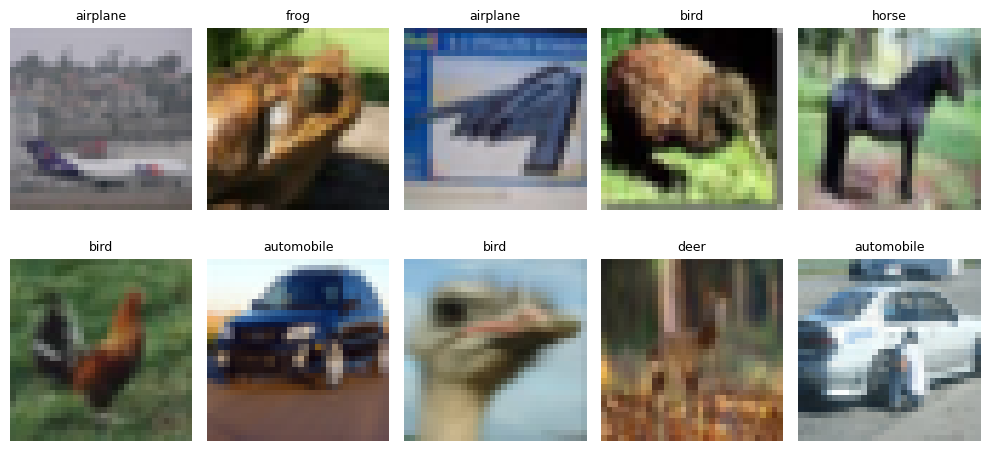

In [15]:
cls = ['airplane','automobile','bird','cat','deer',
       'dog','frog','horse','ship','truck']

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_tr[i])
    plt.title(cls[y_tr[i]], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## Preprocessing
Normalize pixel values 0–255 → 0–1. Flatten for ANN input.

In [16]:
x_tr_n = x_tr / 255.0
x_te_n = x_te / 255.0
x_tr_f = x_tr_n.reshape(len(x_tr_n), -1)
x_te_f = x_te_n.reshape(len(x_te_n), -1)

print("Normalized:", x_tr_n.shape)
print("Flattened :", x_tr_f.shape)

Normalized: (50000, 32, 32, 3)
Flattened : (50000, 3072)


## Part 1 — ANN
ANN treats images as flat vectors — spatial structure is lost.
Input: 32×32×3 = **3072** values per image.

In [17]:
ann = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10,  activation='softmax')
])
ann.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])
ann_h = ann.fit(x_tr_f, y_tr, epochs=10, batch_size=64, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.2638 - loss: 2.0108 - val_accuracy: 0.3178 - val_loss: 1.8691
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.3074 - loss: 1.8862 - val_accuracy: 0.3708 - val_loss: 1.7790
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3329 - loss: 1.8250 - val_accuracy: 0.3710 - val_loss: 1.7544
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3461 - loss: 1.7937 - val_accuracy: 0.3880 - val_loss: 1.7605
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3564 - loss: 1.7682 - val_accuracy: 0.3960 - val_loss: 1.7038
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.3622 - loss: 1.7502 - val_accuracy: 0.4102 - val_loss: 1.6830
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.3697 - loss: 1.7359 - val_accuracy: 0.4042 - val_loss: 1.6902
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3755 - loss: 1.7222 - 

In [18]:
ann_loss, ann_acc = ann.evaluate(x_te_f, y_te, verbose=0)
print(f"ANN Test Accuracy : {ann_acc:.4f}")
print(f"ANN Test Loss     : {ann_loss:.4f}")

ANN Test Accuracy : 0.4293
ANN Test Loss     : 1.6216


## Part 2 — CNN
CNN preserves spatial relationships using convolution, pooling, and hierarchical feature extraction.
Input: **(32, 32, 3)** — full 2D image retained.

In [19]:
cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])
cnn_h = cnn.fit(x_tr_n, y_tr, epochs=10, batch_size=64, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 80ms/step - accuracy: 0.4588 - loss: 1.5152 - val_accuracy: 0.5196 - val_loss: 1.4099
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 73ms/step - accuracy: 0.6023 - loss: 1.1373 - val_accuracy: 0.5970 - val_loss: 1.1715
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 74ms/step - accuracy: 0.6650 - loss: 0.9542 - val_accuracy: 0.6186 - val_loss: 1.0794
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.7100 - loss: 0.8380 - val_accuracy: 0.6420 - val_loss: 1.0722
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 76ms/step - accuracy: 0.7393 - loss: 0.7482 - val_accuracy: 0.6862 - val_loss: 0.9109
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.7679 - loss: 0.6690 - val_accuracy: 0.6840 - val_loss: 0.9850
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.7923 - loss: 0.5915 - val_accuracy: 0.6904 - val_loss: 0.9506
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.8111 - loss: 0.5366 - 

In [20]:
cnn_loss, cnn_acc = cnn.evaluate(x_te_n, y_te, verbose=0)
print(f"CNN Test Accuracy : {cnn_acc:.4f}")
print(f"CNN Test Loss     : {cnn_loss:.4f}")

CNN Test Accuracy : 0.7105
CNN Test Loss     : 0.9486


## Learning Curves — ANN vs CNN

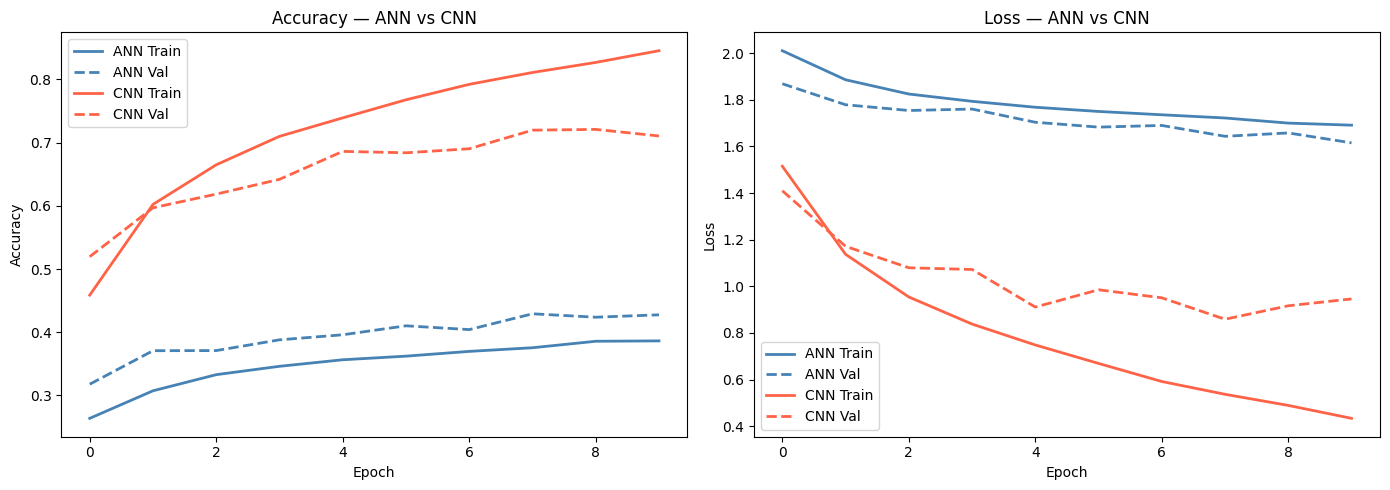

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ann_h.history['accuracy'],     label='ANN Train', color='steelblue', lw=2)
axes[0].plot(ann_h.history['val_accuracy'], label='ANN Val',   color='steelblue', lw=2, ls='--')
axes[0].plot(cnn_h.history['accuracy'],     label='CNN Train', color='tomato',    lw=2)
axes[0].plot(cnn_h.history['val_accuracy'], label='CNN Val',   color='tomato',    lw=2, ls='--')
axes[0].set_title('Accuracy — ANN vs CNN')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(ann_h.history['loss'],     label='ANN Train', color='steelblue', lw=2)
axes[1].plot(ann_h.history['val_loss'], label='ANN Val',   color='steelblue', lw=2, ls='--')
axes[1].plot(cnn_h.history['loss'],     label='CNN Train', color='tomato',    lw=2)
axes[1].plot(cnn_h.history['val_loss'], label='CNN Val',   color='tomato',    lw=2, ls='--')
axes[1].set_title('Loss — ANN vs CNN')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

plt.tight_layout(); plt.show()

## Training Strategy — Data Augmentation
Augmentation generates transformed copies of training images to improve generalization and reduce overfitting.

In [22]:
aug = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])
aug_cnn = models.Sequential([
    aug,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])
aug_cnn.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
aug_h = aug_cnn.fit(x_tr_n, y_tr, epochs=10, batch_size=64, validation_split=0.1)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.3714 - loss: 1.7239 - val_accuracy: 0.4576 - val_loss: 1.5166
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.4732 - loss: 1.4735 - val_accuracy: 0.5244 - val_loss: 1.3128
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.5105 - loss: 1.3808 - val_accuracy: 0.5518 - val_loss: 1.2673
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.5299 - loss: 1.3230 - val_accuracy: 0.5756 - val_loss: 1.1598
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.5500 - loss: 1.2759 - val_accuracy: 0.5706 - val_loss: 1.1817
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.5607 - loss: 1.2369 - val_accuracy: 0.6180 - val_loss: 1.0655
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.5690 - loss: 1.2190 - val_accuracy: 0.6248 - val_loss: 1.0635
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.5788 - loss: 1.1932 - 

In [23]:
aug_loss, aug_acc = aug_cnn.evaluate(x_te_n, y_te, verbose=0)
print(f"Aug CNN Test Accuracy : {aug_acc:.4f}")

Aug CNN Test Accuracy : 0.6330


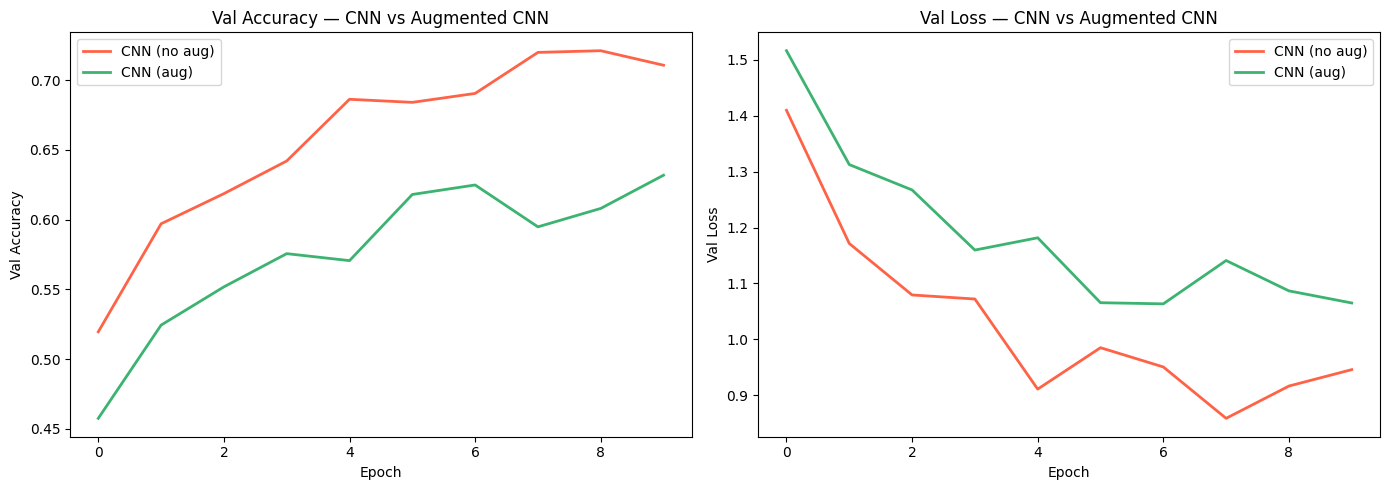

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_h.history['val_accuracy'], label='CNN (no aug)',  color='tomato',       lw=2)
axes[0].plot(aug_h.history['val_accuracy'], label='CNN (aug)',     color='mediumseagreen', lw=2)
axes[0].set_title('Val Accuracy — CNN vs Augmented CNN')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val Accuracy')
axes[0].legend()

axes[1].plot(cnn_h.history['val_loss'], label='CNN (no aug)', color='tomato',        lw=2)
axes[1].plot(aug_h.history['val_loss'], label='CNN (aug)',    color='mediumseagreen', lw=2)
axes[1].set_title('Val Loss — CNN vs Augmented CNN')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## Predictions — CNN on Test Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


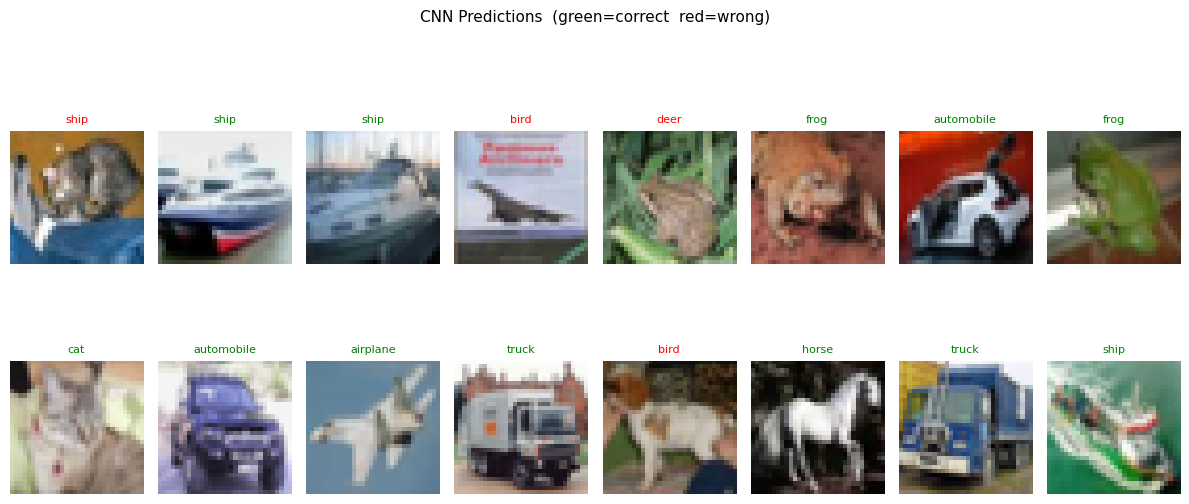

In [25]:
preds = np.argmax(cnn.predict(x_te_n[:16]), axis=1)
plt.figure(figsize=(12, 6))
for i in range(16):
    plt.subplot(2, 8, i+1)
    plt.imshow(x_te[i])
    c = 'green' if preds[i] == y_te[i] else 'red'
    plt.title(cls[preds[i]], fontsize=8, color=c)
    plt.axis('off')
plt.suptitle('CNN Predictions  (green=correct  red=wrong)', fontsize=11)
plt.tight_layout(); plt.show()

## Final Comparison

In [26]:
comp = pd.DataFrame({
    'Model'        : ['ANN', 'CNN', 'CNN + Augmentation'],
    'Test Accuracy': [round(ann_acc,4), round(cnn_acc,4), round(aug_acc,4)],
    'Test Loss'    : [round(ann_loss,4), round(cnn_loss,4), round(aug_loss,4)],
})
comp

,Model,Test Accuracy,Test Loss
0,ANN,0.4293,1.6216
1,CNN,0.7105,0.9486
2,CNN + Augmentation,0.6330,1.0652


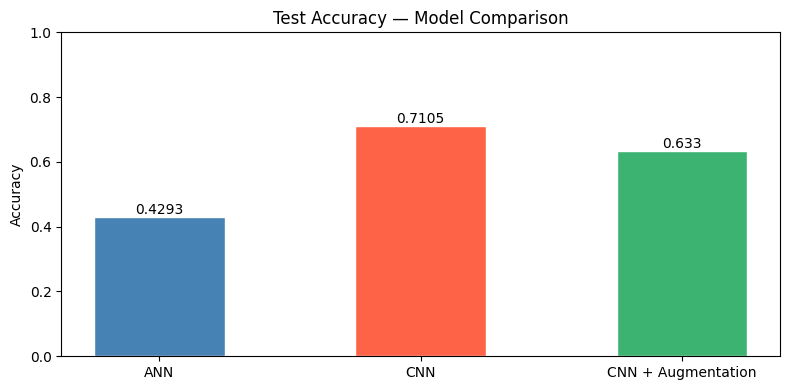

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comp['Model'], comp['Test Accuracy'],
       color=['steelblue','tomato','mediumseagreen'], edgecolor='white', width=0.5)
ax.set_title('Test Accuracy — Model Comparison')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
for i, v in enumerate(comp['Test Accuracy']):
    ax.text(i, v + 0.01, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()